# Project Work NLP: Analisi della Distorsione e Omogeneizzazione della Scrittura da parte degli LLM

Questo notebook esplora l'impatto dei Modelli Linguistici di Grandi Dimensioni (LLM) sulla scrittura umana, implementando un'analisi basata su due recenti studi:

1. L'analisi di *"How LLMs Distort Our Written Language"* (2026), che dimostra come l'uso dell'IA come co-pilota di scrittura tenda a cancellare l'identità dell'autore, generando una "voce algoritmica" omogeneizzata.
2. L'indagine di *"Scientific production in the era of large language models"* (Science, 2025), che evidenzia come l'IA alteri la complessità linguistica spingendo verso un linguaggio iper-formale e artificiale.

Al fine di approfondire sperimentalmente i risultati emersi, questo project work è organizzato in tre esperimenti, ognuno dedicato all'analisi di uno specifico effetto degli LLM sulla produzione testuale.

* **Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche:** analisi di come varia la prevedibilità statistica e la complessità strutturale del testo passando dalla bozza umana iniziale, alla revisione manuale, fino alla revisione artificiale (utilizzando il dataset *ArgRewrite*).
* **Esperimento 2 - Classificazione con Bag of Words e DistilBERT:** analisi delle firme stilistiche dell'IA attraverso due approcci di classificazione: uno basato sulla rappresentazione Bag of Words (BoW) e un classificatore tradizionale, e uno basato sul modello Transformer *DistilBERT*.
* **Esperimento 3 - Omogeneizzazione Lessicale e Sintattica:** replicazione riguardo alla parte di metodologia applicata alle recensioni *ICLR 2026* per misurare la perdita di varietà del vocabolario (tramite Type-Token Ratio) confrontando testi puramente umani e testi generati da IA su un dataset indipendente.

---

### Configurazione dell'Ambiente e Importazione delle Librerie
In questa cella viene configurato l'ambiente importando i pacchetti necessari per la manipolazione dei dati (`pandas`, `numpy`), la visualizzazione grafica (`matplotlib`, `seaborn`), l'estrazione di feature tradizionali e la modellazione classica (`scikit-learn`), e il calcolo delle metriche linguistiche avanzate (`transformers`, `nltk`, `textstat`, `sentence-transformers`).

In [17]:
import os
import re
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import nltk
import textstat

from nltk.tokenize import sent_tokenize, word_tokenize
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    GPT2LMHeadModel, 
    GPT2Tokenizer, 
    DistilBertTokenizer, 
    DistilBertForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from IPython.display import display, Markdown

# Download risorse NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Impostazioni grafiche
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

### Caricamento dei Dati

Prima di estrarre le metriche linguistiche, strutturiamo il dataset in modo da allineare ogni singolo saggio lungo il suo ciclo vitale. 

Attraverso l'integrazione del corpus **ArgRewrite V.2** (per i testi umani) e delle riscritture contenute in `dataframe_essays_llm_model.csv` (per i modelli generativi), costruiamo un unico DataFrame unificato (`df_timeline`). 

Ogni riga del DataFrame rappresenta un saggio tracciato in tre momenti differenti:
1. **$t_0$ - Bozza Iniziale**: il testo grezzo scritto dallo studente prima di ricevere feedback (`Draft1`).
2. **$t_1$ - Revisione Umana**: l'evoluzione naturale del saggio rivista dallo studente a seguito dei commenti (`Draft2`).
3. **$t_1^*$ - Riscrittura IA**: la revisione parallela generata da LLM di riferimento a partire dalla bozza $t_0$ e dal feedback.

Questo allineamento ci permetterà di confrontare direttamente la traiettoria evolutiva dell'apprendimento umano contro la traiettoria di riscrittura con uso dell'IA.

In [2]:
PATH_ANALYSIS = "./data/argrewrite_analysis"
csv_real_path = os.path.join(PATH_ANALYSIS, "dataframe_essays_llm_model.csv")

if os.path.exists(csv_real_path):
    df_raw = pd.read_csv(csv_real_path)
    
    modelli_disponibili = df_raw["llm_model"].unique()
    print(f"[DATA] Modelli LLM presenti nel dataset: {list(modelli_disponibili)}")

    df_filtered = df_raw.copy()
    
    # costruzione del dataFrame timeline
    df_timeline = pd.DataFrame({
        "essay_id": df_filtered["essay_id"],
        "t0_bozza": df_filtered["draft1"],
        "t1_umano": df_filtered["draft2"],
        "t1_ia": df_filtered["ai_text"],
        "llm_model": df_filtered["llm_model"]
    }).dropna().reset_index(drop=True)
    
    print(f"[DATA] Caricamento completato con successo.")
    print(f"[DATA] Totale saggi caricati lungo la timeline: {len(df_timeline)}")
else:
    raise FileNotFoundError(f"Impossibile trovare il file: {csv_real_path}")

[DATA] Modelli LLM presenti nel dataset: ['CLAUDE-HAIKU-4-5-20251001', 'GPT-5-MINI', 'GEMINI-2.5-FLASH']
[DATA] Caricamento completato con successo.
[DATA] Totale saggi caricati lungo la timeline: 2580


---

## Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche

### Obiettivo
In questo primo esperimento misuriamo come si trasforma l'impronta stilistica di un testo durante il suo processo di revisione. La letteratura scientifica suggerisce che l'intervento di un LLM tenda ad "appiattire" il testo, rendendolo più prevedibile e strutturalmente monotono, aumentandone però la complessità sintattica e lessicale.

Analizzeremo l'evoluzione delle grandezze testuali confrontando tre fasi temporali distinte:
1. **$t_0$ - Bozza Iniziale:** il saggio originale scritto dallo studente.
2. **$t_1$ - Revisione Manuale:** il saggio corretto dallo studente seguendo il feedback del docente.
3. **$t_1^*$ - Riscrittura IA:** il saggio originale fatto correggere a un modello IA.

### Metriche Calcolate
Per tracciare questa evoluzione estrarremo quattro grandezze fondamentali:

* **Entropia:** misura il grado di incertezza del modello nel prevedere la parola successiva. Nello specifico, è calcolata come cross-entropy loss utilizzando il modello GPT-2. Testi fortemente standardizzati dall'IA presentano un'entropia minore.
* **Perplessità:** direttamente derivata dall'entropia, indica quanto il testo sia "sorprendente" per un modello linguistico:
  $$Perplexity = \exp(Entropy)$$
* **Burstiness:** valuta la varianza nella lunghezza delle frasi. Gli esseri umani alternano frasi brevi e lunghe (alta burstiness), mentre l'IA tende a produrre strutture di lunghezza uniforme. È calcolata tramite la deviazione standard grezza (non normalizzata) del numero di parole per frase.
* **Leggibilità Flesch:** un indice per quantificare la facilità di lettura. L'obiettivo è verificare se la revisione dell'IA introduca una complessità sintattica artificiale rispetto alla revisione umana.

### Estrattore Metriche Linguistiche

In [4]:
torch.cuda.empty_cache()
device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 70)
print("ESPERIMENTO 1: CALCOLO DELLE METRICHE LINGUISTICHE")
print("=" * 70)
print(f"Dispositivo in uso: {device.upper()}")

# inizializzazione GPT-2 per entropia e perplessità
gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt_model.eval()

def calcola_entropia_perplessita(testo):
    if not isinstance(testo, str) or not testo.strip():
        return np.nan, np.nan
    
    inputs = gpt_tokenizer(testo, return_tensors="pt", truncation=True, max_length=512).to(device)
    if inputs.input_ids.shape[1] < 2:
        return np.nan, np.nan
        
    with torch.no_grad():
        outputs = gpt_model(inputs.input_ids, labels=inputs.input_ids)
        loss = outputs.loss.item()
        perplexity = float(np.exp(loss))
        
    return loss, perplexity

stadi = [
    ("t0", "t0_bozza", "$t_0$ Bozza Umana"),
    ("t1_h", "t1_umano", "$t_1$ Revisione Umana"),
    ("t1_ai", "t1_ia", "$t_1^*$ Riscrittura IA")
]

for prefisso, col_testo, nome_stadio in stadi:
    print(f"\n[{nome_stadio}] Processamento...")
    entropie, perplessita, burstiness, leggibilita = [], [], [], []
    totale = len(df_timeline)
    
    for i, testo in enumerate(df_timeline[col_testo], start=1):
        e, p = calcola_entropia_perplessita(testo)
        
        # burstiness e leggibilità
        if isinstance(testo, str) and testo.strip():
            frasi = nltk.sent_tokenize(testo)
            b = (float(np.std([len(nltk.word_tokenize(f)) for f in frasi])) if len(frasi) > 1 else 0.0)
            l = textstat.flesch_reading_ease(testo)
        else:
            b, l = 0.0, np.nan
            
        entropie.append(e)
        perplessita.append(p)
        burstiness.append(b)
        leggibilita.append(l)
        
        if i % 100 == 0 or i == totale:
            print(f"  Progressione: {i:>4}/{totale} ({i/totale*100:5.1f}%)", end="\r")
    
    df_timeline[f"{prefisso}_entropy"] = entropie
    df_timeline[f"{prefisso}_perplexity"] = perplessita
    df_timeline[f"{prefisso}_burstiness"] = burstiness
    df_timeline[f"{prefisso}_readability"] = leggibilita
    
    print(f"\n  Completato per {nome_stadio}")

torch.cuda.empty_cache()

ESPERIMENTO 1: CALCOLO DELLE METRICHE LINGUISTICHE
Dispositivo in uso: CUDA


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


[$t_0$ Bozza Umana] Processamento...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Progressione: 2580/2580 (100.0%)
  Completato per $t_0$ Bozza Umana

[$t_1$ Revisione Umana] Processamento...
  Progressione: 2580/2580 (100.0%)
  Completato per $t_1$ Revisione Umana

[$t_1^*$ Riscrittura IA] Processamento...
  Progressione: 2580/2580 (100.0%)
  Completato per $t_1^*$ Riscrittura IA


### Visualizzazione Grafica comparativa

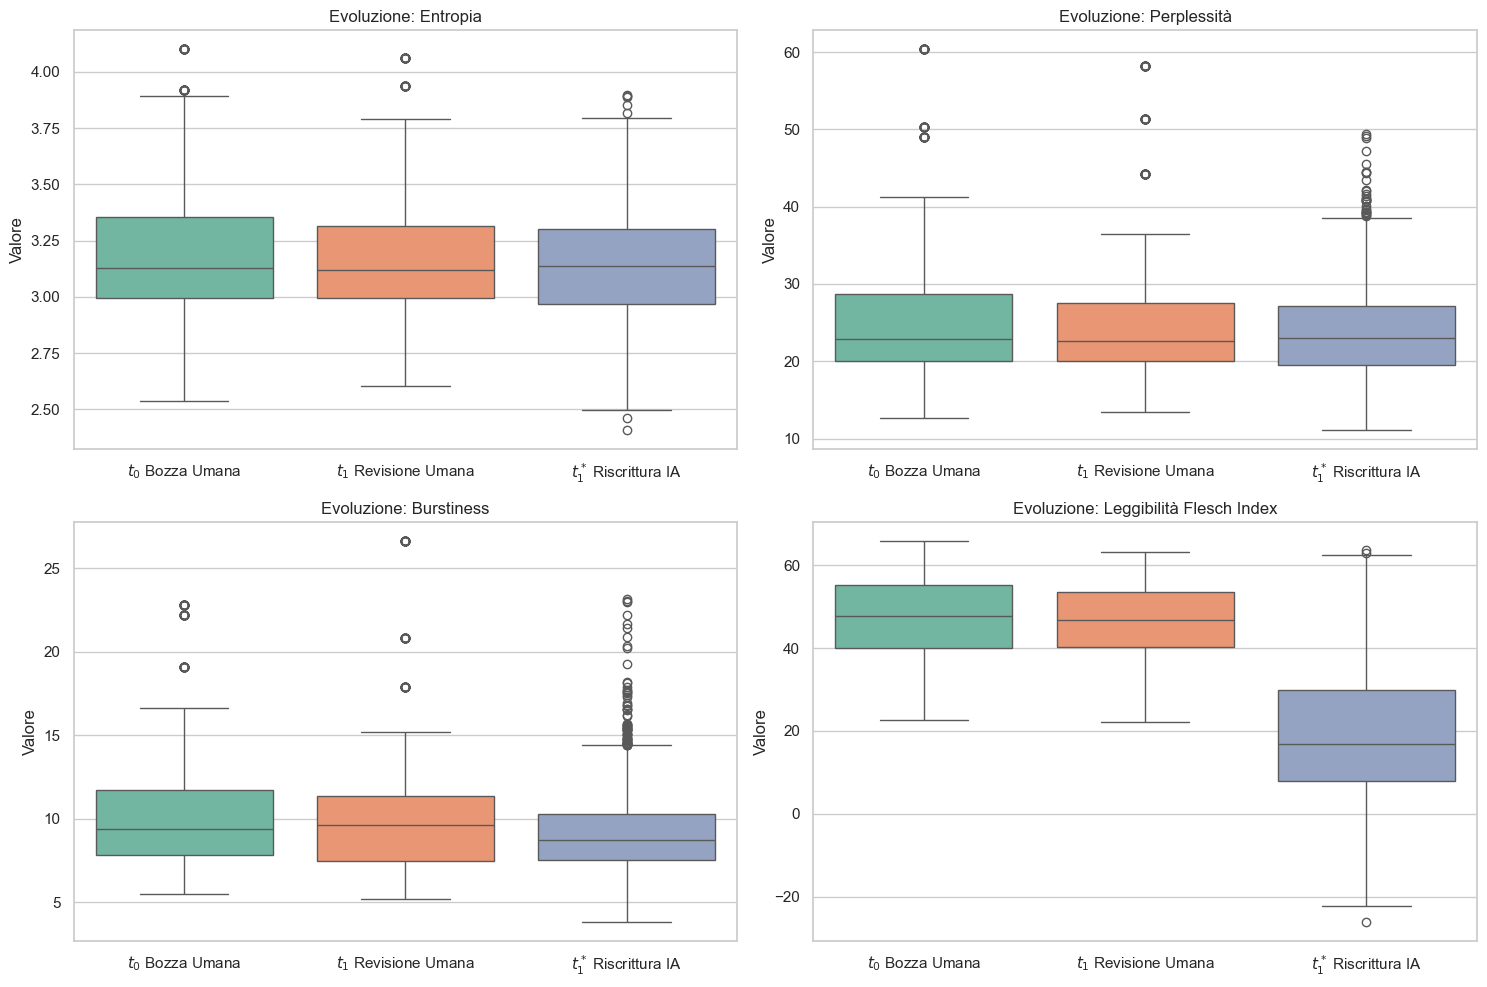

In [5]:
metrics_to_plot = [
    ("entropy", "Entropia"),
    ("perplexity", "Perplessità"),
    ("burstiness", "Burstiness"),
    ("readability", "Leggibilità Flesch Index")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (metric_code, metric_name) in enumerate(metrics_to_plot):
    df_plot = pd.DataFrame({
        "$t_0$ Bozza Umana": df_timeline[f"t0_{metric_code}"],
        "$t_1$ Revisione Umana": df_timeline[f"t1_h_{metric_code}"],
        "$t_1^*$ Riscrittura IA": df_timeline[f"t1_ai_{metric_code}"]
    }).melt(var_name="Stadio", value_name="Valore")
    
    sns.boxplot(data=df_plot, x="Stadio", y="Valore", ax=axes[idx], palette="Set2", hue="Stadio", legend=False)
    axes[idx].set_title(f"Evoluzione: {metric_name}")
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

**Risultati del Grafico**

I quattro boxplot mostrano una differenza evidente tra la revisione umana ($t_1$) e la riscrittura fatta dall’IA ($t_1^*$). La correzione umana mantiene caratteristiche simili al testo originale ($t_0$), mentre l’IA modifica in modo più evidente lo stile del testo.

* **Perplessità ed Entropia:** nel testo riscritto dall’IA ($t_1^*$), i valori sono più concentrati e la mediana è più bassa. Questo significa che il testo è più prevedibile e presenta meno variazioni.
* **Burstiness:** in $t_1^*$ diminuisce la differenza tra le lunghezze delle frasi. Le frasi risultano quindi più simili tra loro e il testo ha un ritmo più uniforme rispetto a $t_0$ e $t_1$.
* **Leggibilità Flesch:** è il cambiamento più evidente. I valori di $t_1^*$ scendono sotto 20, mostrando che il testo prodotto dall’IA è più difficile da leggere, evidenziando l'uso di costrutti più complessi e formali.

In generale, i dati mostrano che l’IA non si limita a migliorare il testo originale, ma ne modifica lo stile. Il testo diventa più uniforme, meno vario e più complesso da leggere.

### Tabella Riassuntiva delle Medie e Deviazioni Standard

In [6]:
metriche_summary = {
    "Stadio": ["$t_0$ - Bozza Umana", "$t_1$ - Revisione Umana", "$t_1^*$ - Riscrittura IA"],
    "Entropy (Media ± Std)": [
        f"{df_timeline['t0_entropy'].mean():.2f} ± {df_timeline['t0_entropy'].std():.2f}",
        f"{df_timeline['t1_h_entropy'].mean():.2f} ± {df_timeline['t1_h_entropy'].std():.2f}",
        f"{df_timeline['t1_ai_entropy'].mean():.2f} ± {df_timeline['t1_ai_entropy'].std():.2f}"
    ],
    "Perplexity (Media ± Std)": [
        f"{df_timeline['t0_perplexity'].mean():.2f} ± {df_timeline['t0_perplexity'].std():.2f}",
        f"{df_timeline['t1_h_perplexity'].mean():.2f} ± {df_timeline['t1_h_perplexity'].std():.2f}",
        f"{df_timeline['t1_ai_perplexity'].mean():.2f} ± {df_timeline['t1_ai_perplexity'].std():.2f}"
    ],
    "Burstiness (Media ± Std)": [
        f"{df_timeline['t0_burstiness'].mean():.2f} ± {df_timeline['t0_burstiness'].std():.2f}",
        f"{df_timeline['t1_h_burstiness'].mean():.2f} ± {df_timeline['t1_h_burstiness'].std():.2f}",
        f"{df_timeline['t1_ai_burstiness'].mean():.2f} ± {df_timeline['t1_ai_burstiness'].std():.2f}"
    ],
    "Leggibilità Flesch (Media ± Std)": [
        f"{df_timeline['t0_readability'].mean():.2f} ± {df_timeline['t0_readability'].std():.2f}",
        f"{df_timeline['t1_h_readability'].mean():.2f} ± {df_timeline['t1_h_readability'].std():.2f}",
        f"{df_timeline['t1_ai_readability'].mean():.2f} ± {df_timeline['t1_ai_readability'].std():.2f}"
    ]
}

df_summary = pd.DataFrame(metriche_summary)
display(Markdown(df_summary.to_markdown(index=False)))

| Stadio                   | Entropy (Media ± Std)   | Perplexity (Media ± Std)   | Burstiness (Media ± Std)   | Leggibilità Flesch (Media ± Std)   |
|:-------------------------|:------------------------|:---------------------------|:---------------------------|:-----------------------------------|
| $t_0$ - Bozza Umana      | 3.18 ± 0.29             | 25.18 ± 8.07               | 10.28 ± 3.33               | 47.09 ± 9.70                       |
| $t_1$ - Revisione Umana  | 3.15 ± 0.28             | 24.21 ± 7.56               | 10.01 ± 3.40               | 46.14 ± 9.37                       |
| $t_1^*$ - Riscrittura IA | 3.13 ± 0.24             | 23.62 ± 5.64               | 9.05 ± 2.30                | 19.58 ± 15.23                      |

**Analisi della Tabella Riassuntiva**

* **Revisione Umana ($t_0 \rightarrow t_1$):** l'intervento umano mantiene inalterato lo stile. La perplessità passa da $25.18 \pm 8.07$ a $24.21 \pm 7.56$, l'entropia da $3.18 \pm 0.29$ a $3.15 \pm 0.28$, la burstiness da $10.28 \pm 3.33$ a $10.01 \pm 3.40$ e la leggibilità da $47.09 \pm 9.70$ a $46.14 \pm 9.37$.
* **Riscrittura IA ($t_1^*$):** l'IA rende il testo più prevedibile e uniforme, si riduce la varianza di entropia ($3.13 \pm 0.24$), perplessità ($23.62 \pm 5.64$) e burstiness ($9.05 \pm 2.30$). Il calo della deviazione standard in tutte le metriche conferma un generale "appiattimento" dello stile.
* **Esplosione della Varianza nella Leggibilità:** il cambiamento più dirompente riguarda la leggibilità Flesch, la cui media crolla a $19.58$, ma la cui deviazione standard schizza a $\pm 15.23$ (un aumento di circa **63%** rispetto alla deviazione standard della revisione umana $t_1$). A differenza delle altre metriche, l'IA non uniforma la leggibilità, ma ne esplode la varianza, producendo testi molto semplici o iper-tecnici.

### Conclusioni Esperimento 1

L'analisi condotta sui **2.580 saggi** mostra una netta differenza tra le correzioni fatte dagli umani e quelle generate dall'IA.

* **Gli umani mantengono lo stile originale ($t_0 \rightarrow t_1$):** la revisione dello studente corregge il testo senza modificarne il ritmo, la leggibilità o la struttura delle frasi.
* **L'IA appiattisce e complica il testo ($t_0 \rightarrow t_1^*$):** la riscrittura automatica standardizza la prevedibilità e la struttura sintattica (minor burstiness) ma destabilizza totalmente la coerenza della leggibilità.

Questa chiara differenza nell'impronta stilistica lascia una traccia digitale evidente e costituisce la base per l'**Esperimento 2**, in cui verificheremo se tali anomalie statistiche permettono a un algoritmo di individuare automaticamente i testi sintetici.

---

## Esperimento 2 - Classificazione con Bag of Words e DistilBERT

### Obiettivo
Questo esperimento ha lo scopo di verificare se le impronte stilistiche lasciate dall'IA ($t_1^*$) siano sufficientemente distinte rispetto al testo scritto dall'umano ($t_0$ e $t_1$) da permettere a un classificatore automatico di individuarle.

Addestreremo un modello **DistilBERT** per un task di classificazione multiclasse su tre categorie:
* **Classe 0 ($t_0$)**: bozza iniziale dello studente.
* **Classe 1 ($t_1$)**: revisione manuale dello studente.
* **Classe 2 ($t_1^*$)**: riscrittura eseguita dall'IA.

### Architettura e Metodologia
1. **Costruzione del Dataset**: unificazione dei testi provenienti dai tre stadi lungo la timeline per un totale di $2.580 \times 3 = 7.740$ campioni.
2. **Split Stratificato**: suddivisione in Train Set (80% - 6.192 campioni) e Test Set (20% - 1.548 campioni).
3. **Parte 1 - Classificazione Avanzata (Fine-Tuning di DistilBERT)**: addestramento del modello Transformer `distilbert-base-uncased` tramite PyTorch per catturare le relazioni contestuali e sintattiche a lungo raggio.
4. **Parte 2 - Baseline Classica (Bag of Words + Logistic Regression)**: vettorializzazione del testo tramite n-grammi e addestramento di un classificatore lineare per misurare la discriminabilità basata sulla sola frequenza dei termini.
5. **Valutazione e Confronto**: analisi comparativa di Accuratezza, Precision, Recall, F1-Score e Matrice di Confusione per entrambi gli approcci.

### Implementazione Codice

#### Parte 1: Classificazione Avanzata con DistilBERT

##### 1. Preparazione Dataset e Dataloader

In [9]:
device_exp2 = torch.device("cpu")
print(f"[INFO] Dispositivo selezionato per l'Esperimento 2: {device_exp2}")

# pulizia preventiva della GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 70)
print("ESPERIMENTO 2: CLASSIFICAZIONE CON BERT (DISTILBERT)")
print("=" * 70)

# costruzione dataset unificato
df_t0 = pd.DataFrame({"text": df_timeline["t0_bozza"].to_list(), "label": 0})
df_t1_h = pd.DataFrame({"text": df_timeline["t1_umano"].to_list(), "label": 1})
df_t1_ai = pd.DataFrame({"text": df_timeline["t1_ia"].to_list(), "label": 2})

df_classification = pd.concat([df_t0, df_t1_h, df_t1_ai], ignore_index=True).dropna()

X_train, X_test, y_train, y_test = train_test_split(
    df_classification["text"].to_numpy(),
    df_classification["label"].to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=df_classification["label"].to_numpy()
)

print(f"[BERT] Campioni di Training: {len(X_train)}")
print(f"[BERT] Campioni di Test:     {len(X_test)}")

[INFO] Dispositivo selezionato per l'Esperimento 2: cpu
ESPERIMENTO 2: CLASSIFICAZIONE CON BERT (DISTILBERT)
[BERT] Campioni di Training: 6192
[BERT] Campioni di Test:     1548


In [10]:
# PyTorch Dataset
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(self.labels[item], dtype=torch.long)
        }

bert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_dataset = TextClassificationDataset(X_train, y_train, bert_tokenizer, max_len=128)
test_dataset = TextClassificationDataset(X_test, y_test, bert_tokenizer, max_len=128)

# size batch ottimizzati per CPU multi-core
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##### 2. Inizializzazione, Fine-Tuning e Valutazione DistilBERT

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[BERT] Avvio Addestramento su CPU...
  Epoch 1/3 | Batch 387/387 | Loss: 0.3215
  Epoch 1 completata. Loss Media: 0.6416
  Epoch 2/3 | Batch 387/387 | Loss: 0.1886
  Epoch 2 completata. Loss Media: 0.2725
  Epoch 3/3 | Batch 387/387 | Loss: 0.6536
  Epoch 3 completata. Loss Media: 0.2120

REPORT DI CLASSIFICAZIONE BERT
                    precision    recall  f1-score   support

    t0 Bozza Umana       0.76      0.96      0.85       516
t1 Revisione Umana       0.94      0.83      0.88       516
t1* Riscrittura IA       1.00      0.87      0.93       516

          accuracy                           0.88      1548
         macro avg       0.90      0.88      0.89      1548
      weighted avg       0.90      0.88      0.89      1548



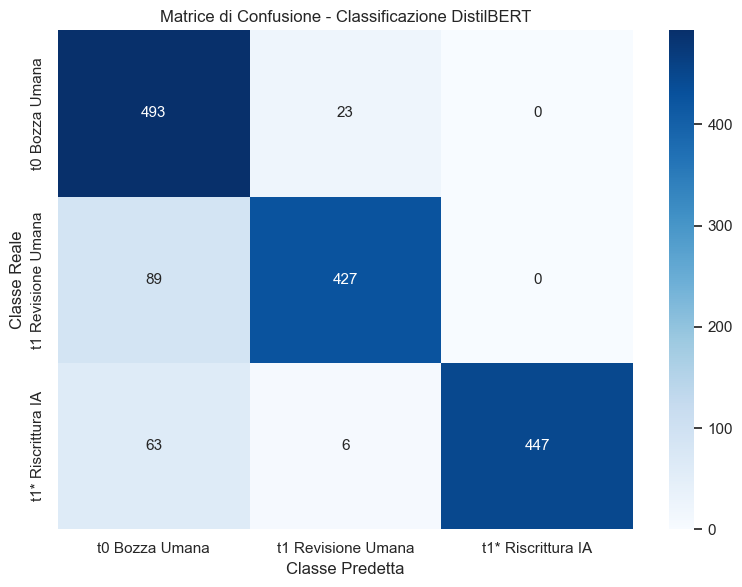

In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=3
).to(device_exp2)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)
epochs = 3

# training Loop
print("\n[BERT] Avvio Addestramento su CPU...")
for epoch in range(epochs):
    bert_model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(device_exp2)
        attention_mask = batch["attention_mask"].to(device_exp2)
        labels = batch["label"].to(device_exp2)
        
        outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        # monitoro avanazamento
        if batch_idx % 50 == 0 or batch_idx == len(train_loader):
            print(f"  Epoch {epoch+1}/{epochs} | Batch {batch_idx:>3}/{len(train_loader)} | Loss: {loss.item():.4f}", end="\r")
            
    print(f"\n  Epoch {epoch+1} completata. Loss Media: {total_loss/len(train_loader):.4f}")

# valutazione metriche
bert_model.eval()
# liste predizioni e etichette reali
y_preds = []
y_trues = []

# disabilito calcolo gradienti
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device_exp2)
        attention_mask = batch["attention_mask"].to(device_exp2)
        labels = batch["label"].to(device_exp2)
        
        outputs = bert_model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        y_preds.extend(preds.cpu().numpy())
        y_trues.extend(labels.cpu().numpy())

target_names = ["t0 Bozza Umana", "t1 Revisione Umana", "t1* Riscrittura IA"]

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE BERT")
print("=" * 70)
print(classification_report(y_trues, y_preds, target_names=target_names))

# matrice di confusione
cm = confusion_matrix(y_trues, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice di Confusione - Classificazione DistilBERT")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione DistilBERT

I risultati della classificazione con DistilBERT confermano con elevata accuratezza (**88%**) la separabilità stilometrica tra le fasi del testo:

* **Precisione Assoluta sull'IA ($t_1^* = 1.00$):** la precision del **100%** sulla classe $t_1^*$ indica l'assenza totale di falsi positivi: nessun testo scritto o revisionato da un umano è stato scambiato per un testo generato dall'IA. Questo risultato è coerente con i risultati dell'**Esperimento 1**, dove gli interventi dell'IA hanno mostrato alterazioni stilometriche estreme (es. crollo della leggibilità Flesch a ~19).
* **Margine di Errore (Recall $t_1^* = 0.87$):** il modello non è tuttavia infallibile: presenta una recall dell'**87%** sulla classe IA. Su 516 campioni $t_1^*$ totali, 447 sono stati classificati correttamente, generando esattamente 69 falsi negativi (di cui 63 scambiati per bozza $t_0$ e 6 per revisione $t_1$). Ciò dimostra che in una piccola percentuale di casi l'IA produce modifiche che si mimetizzano perfettamente con la scrittura dello studente.
* **Coerenza tra $t_0$ e $t_1$:** la principale fonte di confusione del modello si registra tra la bozza iniziale e la revisione umana, con 89 campioni $t_1$ predetti come $t_0$ (e 23 campioni $t_0$ scambiati per $t_1$). Questo disorientamento del classificatore è coerente con i risultati ottenuti nell’**Esperimento 1**, evidenziando come la correzione umana possa migliorare la qualità del testo senza modificarne in modo significativo le caratteristiche stilistiche.

#### Parte 2: Classificazione Baseline con Bag of Words (BoW) + Logistic Regression

ESPERIMENTO 2: CLASSIFICAZIONE BAG OF WORDS (BoW)
[BoW] Dimensione Vocabolario Estratto: 5000 feature

REPORT DI CLASSIFICAZIONE BAG OF WORDS (Logistic Regression)
                    precision    recall  f1-score   support

    t0 Bozza Umana       0.96      1.00      0.98       516
t1 Revisione Umana       1.00      1.00      1.00       516
t1* Riscrittura IA       1.00      0.96      0.98       516

          accuracy                           0.99      1548
         macro avg       0.99      0.99      0.99      1548
      weighted avg       0.99      0.99      0.99      1548



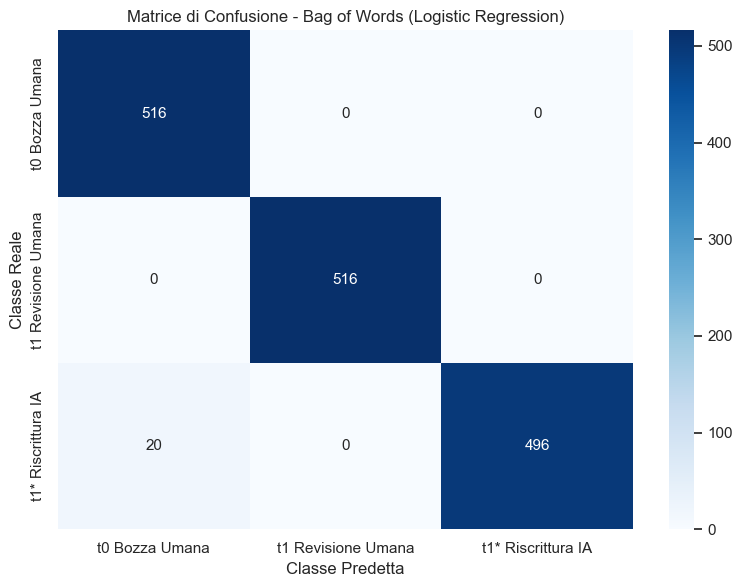

In [14]:
print("=" * 70)
print("ESPERIMENTO 2: CLASSIFICAZIONE BAG OF WORDS (BoW)")
print("=" * 70)

# definizione locale di target_names per rendere la cella indipendente da quella di DistilBERT
target_names = ["t0 Bozza Umana", "t1 Revisione Umana", "t1* Riscrittura IA"]

# vettorializzazione del testo tramite CountVectorizer
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"[BoW] Dimensione Vocabolario Estratto: {X_train_bow.shape[1]} feature")

# Logistic Regression
clf_bow = LogisticRegression(max_iter=1000, random_state=42)
clf_bow.fit(X_train_bow, y_train)

# predizione e valutazione
y_pred_bow = clf_bow.predict(X_test_bow)

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE BAG OF WORDS (Logistic Regression)")
print("=" * 70)
print(classification_report(y_test, y_pred_bow, target_names=target_names))

# Matrice di Confusione BoW
cm_bow = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice di Confusione - Bag of Words (Logistic Regression)")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione Bag of Words (BoW) + Logistic Regression

I risultati della classificazione basata su Bag of Words mostrano metriche quasi perfette, raggiungendo un'accuratezza complessiva del **99%**. Tuttavia, questo risultato appare anomalo se confrontato con il modello contestuale DistilBERT (**88%**):

* **Precisione assoluta su $t_1^*$ (Precision = 1.00)**: la precision del **100%** sulla classe $t_1^*$ indica l'assenza totale di falsi positivi: nessun testo appartenente a $t_0$ o $t_1$ è stato classificato come riscrittura IA. Questo evidenzia come il modello riconosca in modo netto i testi generati sinteticamente.

* **Margine di errore su $t_1^*$ (Recall = 0.96)**: il modello presenta una recall del **96%** sulla classe $t_1^*$. Su 516 campioni $t_1^*$, 496 sono stati classificati correttamente, mentre solo 20 sono stati classificati erroneamente come $t_0$ (e 0 come $t_1$). Questo rappresenta l'unico margine di errore dell'intero classificatore, dove una piccolissima parte delle modifiche dell'IA viene scambiata per la bozza iniziale.

* **Sovrapposizione tra $t_0$ e $t_1$**:  a differenza di DistilBERT, nel modello BoW non si registra alcuna confusione tra la bozza iniziale $t_0$ e la revisione umana $t_1$. Tutti i 516 campioni $t_0$ e i 516 campioni $t_1$ sono stati classificati con una recall del **100%**. Questa assenza di sovrapposizione tra testo originale e revisione manuale appare irrealistica per un'analisi stilometrica e suggerisce la presenza di marcatori superficiali memorizzati dal modello.

### Diagnosi del Data Leakage: Ispezione dei Coefficienti

Per verificare l'ipotesi di data leakage e identificare gli artefatti superficiali che permettono al modello lineare di raggiungere un'accuratezza del **99%**, si rende necessaria un'analisi delle feature apprese. In questa sezione si estrae e ordina i coefficienti della Logistic Regression, isolando per ciascuna classe ($t_0$, $t_1$, $t_1^*$) i 10 n-grammi con il peso decisionale maggiore. Questa ispezione permette di verificare se il classificatore stia apprendendo una vera struttura stilometrica o se stia semplicemente memorizzando espressioni chiave, connettivi formali o marcatori di dominio specifici.

In [15]:
# recupero dei nomi delle feature dal vettorializzatore
feature_names = np.array(bow_vectorizer.get_feature_names_out())

print("=" * 70)
print("ANALISI DEI COEFFICIENTI BAG OF WORDS (TOP 10 PAROLE PER CLASSE)")
print("=" * 70)

# estrazione delle 10 parole con peso maggiore per ciascuna classe
for i, class_label in enumerate(target_names):
    top_indices = np.argsort(clf_bow.coef_[i])[-10:]
    top_words = feature_names[top_indices]
    top_weights = clf_bow.coef_[i][top_indices]
    
    df_top = pd.DataFrame({
        "Parola/N-gramma": top_words,
        "Peso (Coefficiente)": np.round(top_weights, 4)
    }).sort_values(by="Peso (Coefficiente)", ascending=False)
    
    print(f"\n---> Classe: [{class_label}]")
    print(df_top.to_string(index=False))

ANALISI DEI COEFFICIENTI BAG OF WORDS (TOP 10 PAROLE PER CLASSE)

---> Classe: [t0 Bozza Umana]
Parola/N-gramma  Peso (Coefficiente)
             ed               0.9985
      questions               0.8263
 cause accident               0.8209
         saving               0.7470
           risk               0.7458
           able               0.7294
       everyday               0.7175
            don               0.6651
           long               0.6435
        knowing               0.6090

---> Classe: [t1 Revisione Umana]
Parola/N-gramma  Peso (Coefficiente)
         easily               0.8730
           fail               0.7799
          quite               0.7194
     minimizing               0.6967
          lower               0.6820
         having               0.6702
  question self               0.6637
        benefit               0.6425
    driven cars               0.6005
        society               0.5989

---> Classe: [t1* Riscrittura IA]
Parola/N-gramma  Pes

### Interpretazione dei Coefficienti ed Evidenza del Data Leakage

L'ispezione dei coefficienti conferma che l'accuratezza del **99%** deriva da scorciatoie lessicali e artefatti di contenuto, anziché da una reale sensibilità stilometrica:

* **$t_0$ (Bozza Umana)**: caratterizzata da forme informali, contrazioni e stesura primaria (es. *don*, *ed*, *knowing*).

* **$t_1$ (Revisione Umana)**: dominata dall'introduzione di connettivi logici e avverbi formali (es. *furthermore*, *quite*, *minimizing*).

* **Bigrammi e N-grammi di dominio**: la presenza di termini specifici dell'argomento (es. *cause accident*, *human drivers*) dimostra che il modello memorizza il contenuto dei singoli testi anziché rilevarne lo stile (data leakage).

Di conseguenza, per osservare il comportamento effettivo del modello Bag of Words al netto di queste distorsioni, proveremo a ricalibrare la baseline. L'impiego di `TfidfVectorizer` limitato ai soli unigrammi permetterà di escludere i n-grammi di dominio e riequilibrare l'impatto delle parole più frequenti.

### Implementazione della Baseline Ricalibrata

ESPERIMENTO 2 (RICALIBRATO): CLASSIFICAZIONE TF-IDF
[TF-IDF] Dimensione Vocabolario Estratto: 2000 feature

REPORT DI CLASSIFICAZIONE TF-IDF (Logistic Regression)
                    precision    recall  f1-score   support

    t0 Bozza Umana       0.91      1.00      0.95       516
t1 Revisione Umana       0.99      1.00      0.99       516
t1* Riscrittura IA       1.00      0.88      0.94       516

          accuracy                           0.96      1548
         macro avg       0.96      0.96      0.96      1548
      weighted avg       0.96      0.96      0.96      1548



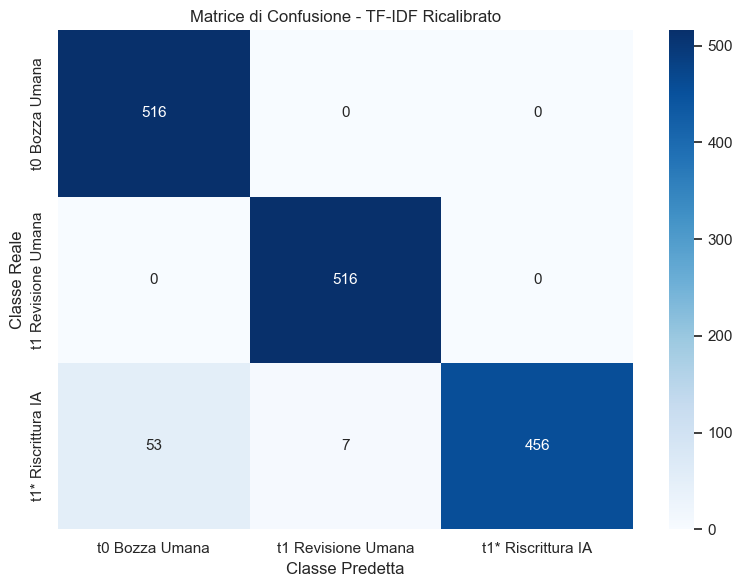

In [18]:
print("=" * 70)
print("ESPERIMENTO 2 (RICALIBRATO): CLASSIFICAZIONE TF-IDF")
print("=" * 70)

# 1. Vettorializzazione TF-IDF (solo unigrammi per escludere n-grammi di dominio)
tfidf_vectorizer = TfidfVectorizer(
    max_features=2000, 
    ngram_range=(1, 1), 
    stop_words="english",
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"[TF-IDF] Dimensione Vocabolario Estratto: {X_train_tfidf.shape[1]} feature")

# 2. Addestramento Logistic Regression
clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)

# 3. Predizione e Valutazione
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE TF-IDF (Logistic Regression)")
print("=" * 70)
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

# Matrice di Confusione TF-IDF
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice di Confusione - TF-IDF Ricalibrato")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione TF-IDF Ricalibrato

L'introduzione della vettorializzazione TF-IDF limitata ai soli unigrammi riduce l'accuratezza complessiva dal **99% al 96%**. Sebbene la matrice di confusione appaia visivamente molto simile a quella di Bag of Words + Logistic Regression, l'analisi dei dati evidenzia:

* **Precisione assoluta su $t_1^*$ (Precision = 1.00):** anche dopo la ricalibrazione, la precision sulla classe $t_1^*$ rimane al **100%**. Nessun testo scritto o revisionato da un umano ($t_0$ o $t_1$) viene scambiato per una riscrittura sintetica, confermando l'assenza totale di falsi positivi per la classe IA.
* **Aumento del margine di errore su $t_1^*$ (Recall = 0.88):** eliminando i bigrammi di contenuto memorizzati nel primo esperimento, la capacità del modello di individuare l'IA scende dal **96% all'88%**. Gli errori di classificazione per $t_1^*$ triplicano (da 20 a 60 campioni su 516): **53 testi IA vengono scambiati per la bozza $t_0$** e **7 per la revisione $t_1$**. La recall su $t_1^*$ si allinea così esattamente a quella registrata da DistilBERT (**88%**).
* **Persistenza della separazione tra $t_0$ e $t_1$ (Recall = 1.00):** la ricalibrazione non altera la perfetta separazione tra la bozza iniziale $t_0$ e la revisione umana $t_1$, mantenendo il **100%** di recall su entrambe. Questo evidenzia un limite strutturale dei modelli basati sulla frequenza: la semplice presenza di singoli avverbi o connettivi formali (es. *furthermore*, *minimizing*), tipici della revisione manuale, basta al classificatore lineare per dividere nettamente le due classi, rendendolo incapace di cogliere la continuità stilistica tra autore e testo revisionato.

### Conclusioni Esperimento 2

L'Esperimento 2 evidenzia le differenze tra modelli frequenziali tradizionali BoW, TF-IDF e architetture basate su Transformer DistilBERT nella classificazione della provenienza del testo tra bozza ($t_0$), revisione umana ($t_1$) e riscrittura sintetica ($t_1^*$).

* **Rilevamento dell'IA e Convergenza delle Metriche:** tutti i classificatori mostrano una precisione del **100%** su $t_1^*$, garantendo l'assenza di falsi positivi sulle classi umane. Rimuovendo i bi-grammi di dominio con la ricalibrazione TF-IDF, la *recall* del modello lineare scende dal **96% all'88%**, allineandosi a quella di DistilBERT (**88%**). Ciò indica che circa il **12%** dei testi riscritti dall'IA presenta interventi abbastanza contenuti da mimetizzarsi con la produzione dello studente.

* **Limiti dei Modelli Frequenziali vs Rappresentazione Contestuale ($t_0$ vs $t_1$):** la principale discrepanza riguarda il rapporto tra bozza e revisione manuale. I modelli basati su conteggi lessicali separano $t_0$ e $t_1$ con una recall artificiale del **100%**, basandosi sulla semplice presenza di singoli avverbi o connettivi formali (es. *furthermore*, *minimizing*). DistilBERT, invece, cattura le dipendenze contestuali e la continuità dello stile della scrittura, riconoscendo che la revisione umana migliora la forma senza alterare la struttura profonda del testo.

* **Ispezione dei Coefficienti e Diagnosi di Data Leakage:** l'analisi dei pesi della Logistic Regression è stata determinante per rilevare il *leakage* della baseline BoW originale. L'isolamento dei coefficienti ha mostrato come il modello lineare memorizzasse sequenze legate al contenuto (es. *cause accident*, *human drivers*). Scegliendo il TF-IDF su unigrammi è stato possibile rimuovere questi elementi artificiali, ottenendo così una baseline  lineare.

I risultati validano le evidenze dell'**Esperimento 1**, confermando che la riscrittura introduce alterazioni di stile ben tracciabili. Allo stesso tempo, l'analisi dimostra che solo un modello come DistilBERT è in grado di distinguere l'evoluzione di un testo umano da una riscrittura senza andare in *overfitting* su singoli marcatori lessicali.

---

## Esperimento 3 - Omogeneizzazione Lessicale e Sintattica

### Obiettivo
Questo terzo esperimento estende l'analisi alla varianza semantica, prendendo spunto dagli studi sull'omogeneizzazione generata dall'IA (es. ICLR 2026).

L'obiettivo è misurare il fenomeno della convergenza lessicale e semantica nei testi prodotti dagli LLM, applicando questa prospettiva a un nuovo dataset. Si vuole dimostrare che, sebbene gli LLM producano testi sintatticamente complessi, tendono a convergere verso un "vocabolario" standardizzato, appiattendo la ricchezza lessicale tipica di un gruppo di scrittori umani.

### Metriche per quantificare l'omogeneizzazione

Per quantificare l'omogeneizzazione vengono analizzate due mentriche complementari:

1. **Ricchezza Lessicale (Standardized Type-Token Ratio - STTR):** calcolata su una finestra standard di **150 token** per eliminare il bias legato alla lunghezza dei documenti.

2. **Diversità Sintattica e Strutturale (Distinct-N):** misura la quota di **N-grammi unici** ($N \in \{1, 2, 3\}$) sul totale delle sequenze.

### Dataset: HC3 Finance

Per questo esperimento utilizzeremo un sottoinsieme di **HC3**, focalizzato sul dominio finanziario (`Atharva07/hc3_finance`). 

Questo dataset raccoglie migliaia di domande di economia, per ciascuna delle quali abbiamo:
* **Risposta Umana:** caratterizzato da un possibile uso di gergo tecnico e da variazioni di tono tipiche dei forum umani.
* **Risposta IA (ChatGPT):** generata da IA, che potrebbe invece presentare un linguaggio più neutro e maggiormente uniforme.

Estraendo per ogni domanda esattamente una risposta umana e una sintetica, costruiremo un campione bilanciato (1:1).

In [13]:
print("=" * 70)
print("ESPERIMENTO 3: CARICAMENTO CORRETTO E CALCOLO STTR")
print("=" * 70)

# caricamento dataset
print("[INFO] Download dataset in corso...")
dataset = load_dataset("Atharva07/hc3_finance")
df_raw = pd.DataFrame(dataset['train'])

# estrazione testi
def safe_extract(val):
    if isinstance(val, list) and len(val) > 0:
        return str(val[0]).strip()
    elif isinstance(val, str) and len(val.strip()) > 0:
        return val.strip()
    return None

testi_umani = []
testi_ia = []

for idx, row in df_raw.iterrows():
    h_ans = safe_extract(row['human_answers'])
    ai_ans = safe_extract(row['chatgpt_answers'])
    
    if h_ans and ai_ans:
        testi_umani.append(h_ans)
        testi_ia.append(ai_ans)

# creazione dataframe bilanciato
df_exp3 = pd.DataFrame({
    "text": testi_umani + testi_ia,
    "label": ["Umano"] * len(testi_umani) + ["IA"] * len(testi_ia)
})

print(f"[DATA] Coppie estratte con successo: {len(testi_umani)}")
print(f"[DATA] Totale testi: {len(df_exp3)}")

ESPERIMENTO 3: CARICAMENTO CORRETTO E CALCOLO STTR
[INFO] Download dataset in corso...
[DATA] Coppie estratte con successo: 3104
[DATA] Totale testi: 6208


### Fase 1: Calcolo della Ricchezza Lessicale (TTR)

Per quantificare la varietà del vocabolario utilizzato nei due insiemi, calcoleremo il **Type-Token Ratio (TTR)**. Questa metrica mette in rapporto il numero di parole uniche (Type) con il numero totale di parole (Token) presenti in un documento:

$$TTR = \frac{\text{Type}}{\text{Token}}$$

* **Valori più alti** indicano un testo lessicalmente ricco e variegato, tipico della scrittura umana (che include gergo, sinonimi e metafore).
* **Valori più bassi** indicano un testo ripetitivo e conservativo.

Per evitare che testi più lunghi penalizzino il punteggio, si adotta lo Standardized TTR (STTR) fisso sui primi 150 token di ogni risposta.

### Implentazione Codice

[BIAS] Testi umani validi: 1415/3104 (45.6%)
[BIAS] Testi IA validi: 2618/3104 (84.3%)
[INFO] Testi totali rimasti (≥ 150 token): 4033 su 6208


,mean,std,min,max,count
label,,,,,
IA,0.5197,0.0640,0.2733,0.6867,2618
Umano,0.6158,0.0598,0.3267,0.7800,1415


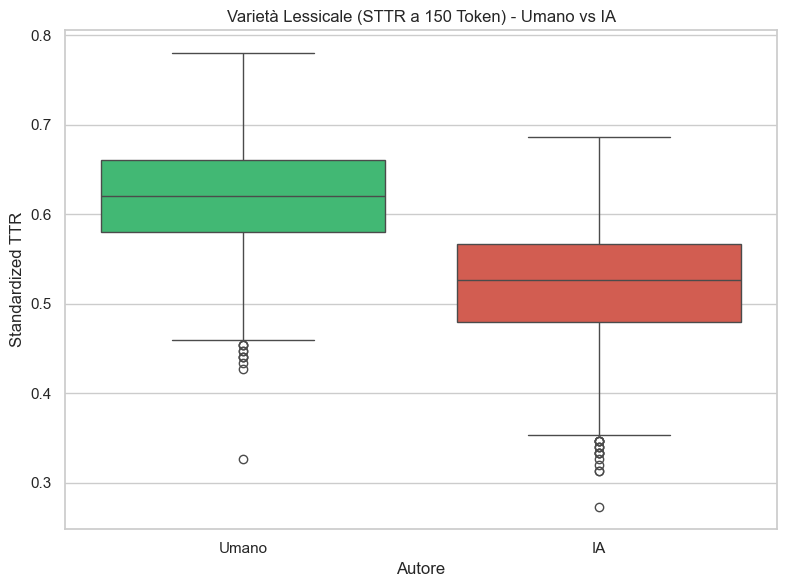

In [14]:
MAX_TOKENS = 150

def get_sttr(text, MAX_TOKENS):
    tokens = re.findall(r'\b\w+\b', text.lower())
    if len(tokens) < MAX_TOKENS:
        return None  # scarto testi con meno di 150 parole
    
    tokens_sub = tokens[:MAX_TOKENS]
    types = set(tokens_sub)
    return len(types) / len(tokens_sub)

df_exp3["STTR"] = df_exp3["text"].apply(lambda x: get_sttr(x, MAX_TOKENS))

# Calcolo del Survivorship Bias
human_tot = len(df_exp3[df_exp3["label"] == "Umano"])
ai_tot = len(df_exp3[df_exp3["label"] == "IA"])
human_surv = df_exp3[df_exp3["label"] == "Umano"]["STTR"].notna().sum()
ai_surv = df_exp3[df_exp3["label"] == "IA"]["STTR"].notna().sum()

print(f"[BIAS] Testi umani validi: {human_surv}/{human_tot} ({(human_surv/human_tot)*100:.1f}%)")
print(f"[BIAS] Testi IA validi: {ai_surv}/{ai_tot} ({(ai_surv/ai_tot)*100:.1f}%)")

df_clean = df_exp3.dropna(subset=["STTR"]).copy()
print(f"[INFO] Testi totali rimasti (≥ {MAX_TOKENS} token): {len(df_clean)} su {len(df_exp3)}")

stats_ttr = df_clean.groupby("label")["STTR"].agg(["mean", "std", "min", "max", "count"]).round(4)
display(stats_ttr)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x="label", y="STTR", hue="label", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("Varietà Lessicale (STTR a 150 Token) - Umano vs IA")
plt.xlabel("Autore")
plt.ylabel("Standardized TTR")
plt.tight_layout()
plt.show()

**Nota**: L'applicazione della soglia sul numero di token fa emergere una forte asimmetria strutturale. Solo circa il **46%** circa dei testi umani raggiunge i 150 token, contro l'84% di quelli generati dall'IA. Oltre a confermare che l'IA genera testi sistematicamente più lunghi, questo filtro introduce un bias: il calcolo dello **STTR** finirà per confrontare l'intero spettro produttivo dell'IA esclusivamente con la parte dei testi umani più lunghi.

### Analisi dei Risultati: Type-Token Ratio (STTR)

L'analisi della ricchezza lessicale, calcolata sui primi 150 token, conferma l'ipotesi di omogeneizzazione del vocabolario nell'IA:

* **Compressione Lessicale dell'IA:** il modello linguistico presenta un STTR medio di $0.52$, indicando una spiccata tendenza a riutilizzare lo stesso set di parole, congiunzioni e strutture.
* **Varianza Umana:** gli autori umani mantengono una media nettamente superiore (circa $0.62$) e raggiungono picchi di varietà molto più alti (fino a un massimo di $0.78$), un valore che l'IA non riesce mai a sfiorare (fermandosi a un massimo di $0.69$).
* **Significatività:** il boxplot evidenzia come l'intera distribuzione generata dall'IA sia traslata verso il basso. Nonostante il dominio finanziario sia vincolato a un gergo specifico, gli umani riescono a esprimere i concetti con una maggiore diversità di vocaboli rispetto al pattern standard di ChatGPT.

## Fase 2: Diversità Sintattica e Strutturale (Distinct-N)

Per verificare se l'omogeneizzazione riguardi anche le **strutture di frase** e le **combinazioni di parole**, è stata calcolata la metrica **Distinct-N** per:

1. **N = 1** → unigrammi
2. **N = 2** → bigrammi
3. **N = 3** → trigrammi

Per evitare distorsioni statistiche legate alle dimensioni complessive dei due dataset (in linea con la Legge di Heaps, secondo cui la varietà lessicale diminuisce all'aumentare della lunghezza del testo), la metrica non è calcolata sull'intero corpus,ma valutata per singola risposta (sempre sulla finestra standard di 150 token), estraendone successivamente la media aritmetica.

La formula è:

$$\text{Distinct-N} = \frac{\text{Numero di N-grammi Unici}} {\text{Numero Totale di N-grammi}}$$

In [ ]:
def calculate_distinct_n_per_doc(texts, n=2):
    scores = []
    for t in texts:
        # dividiamo il testo in frasi separate. Così facciamo in modo che l'ultima parola della frase 1 e la prima parola della frase 2 non si uniscano per sbaglio.
        sentences = sent_tokenize(t.lower())
        
        ngrams = []
        for sentence in sentences:
            # tokenizziamo la singola frase rimuovendo la punteggiatura
            tokens = [w for w in word_tokenize(sentence) if w.isalnum()]
            
            # estraiamo gli n-grammi solo all'interno della stessa frase
            if len(tokens) >= n:
                sentence_ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
                ngrams.extend(sentence_ngrams)
        
        # calcoliamo la varietà di parole per singolo testo. Dividiamo le coppie uniche (senza duplicati) per il totale delle coppie trovate.
        if ngrams:
            score = len(set(ngrams)) / len(ngrams)
            scores.append(score)
    
    if not scores:
        return 0.0
    return sum(scores) / len(scores)

testi_clean_human = df_clean[df_clean["label"] == "Umano"]["text"].tolist()
testi_clean_ai = df_clean[df_clean["label"] == "IA"]["text"].tolist()

print("=" * 70)
print("ANALISI DISTINCT-N (MEDIA PER SINGOLA RISPOSTA)")
print("=" * 70)

results = []
for n in [1, 2, 3]:
    d_human = calculate_distinct_n_per_doc(testi_clean_human, n=n)
    d_ai = calculate_distinct_n_per_doc(testi_clean_ai, n=n)
    drop = ((d_human - d_ai) / d_human) * 100
    results.append({
        "N-Gram": f"Distinct-{n}", 
        "Umano": round(d_human, 4), 
        "IA": round(d_ai, 4), 
        "Crollo IA (%)": f"-{round(drop, 1)}%"
    })

df_distinct = pd.DataFrame(results)
display(df_distinct)

ANALISI DISTINCT-N (MEDIA PER SINGOLA RISPOSTA)


,N-Gram,Umano,IA,Crollo IA (%)
0,Distinct-1,0.5297,0.4662,-12.0%
1,Distinct-2,0.8989,0.8037,-10.6%
2,Distinct-3,0.9697,0.9020,-7.0%


### Interpretazione dei Risultati

1. **Unigrammi (Distinct-1: -12%)**: La percentuale di vocaboli unici per singola risposta scende da $0.529$ (umani) a $0.466$ (IA). Questo conferma un vocabolario più ristretto e una tendenza sistematica del modello a riciclare le stesse parole all'interno del testo.

2. **Bigrammi (Distinct-2: -10.6%)**: Anche la varietà delle coppie di parole si riduce. Il modello tende quindi a ricorrere più frequentemente alle stesse combinazioni lessicali e collocazioni, come per esempio *"interest rate"*, *"tax return"*, *"make sure"*, rendendo il ritmo della risposta più uniforme e prevedibile rispetto alla variabilità umana.

3. **Trigrammi (Distinct-3: -7%)**: La riduzione delle sequenze di tre parole conferma che l'omogeneizzazione riguarda anche la sintassi. Il modello tende infatti a utilizzare formule e costruzioni ricorrenti, come *"it is important"*, *"in order to"*, *"on the other"*), riducendo la varietà delle modalità espressive.

### Conclusioni dell'Esperimento 3

L'**Esperimento 3** dimostra che l'omogeneizzazione generata dai modelli linguistici non riguarda principalmente la perdita dei contenuti concettuali, quanto piuttosto un marcato collasso della **diversità stilistica, lessicale e sintattica**, cioè il modo in cui questi vengono espressi:

* **Efficienza a scapito della varietà:** ChatGPT riesce a trasmettere i concetti richiesti, ma tende a farlo attraverso un insieme più ristretto di vocaboli e strutture linguistiche.

* **Firma linguistica ristretta:** il calo di **STTR (-15.6% sulla media per singolo documento)** e **Distinct-N (-10.6% sui bigrammi)** evidenzia una maggiore ripetitività sia a livello lessicale che nelle combinazioni tra parole.

* **Survivorship Bias e illusione della prolissità**: il filtro applicato ai testi di almeno 150 token mette in evidenza un possibile problema statistico. I testi generati dall’IA tendono infatti a essere più lunghi: l’**84%** dei campioni sintetici supera questa soglia, rispetto al **46%** dei testi umani. Questo può creare l’impressione che i testi generati dall’IA siano più complessi o sofisticati. Tuttavia, considerando testi della stessa lunghezza, questa differenza si riduce e emerge una maggiore ripetitività nello stile dei testi generati.

In sintesi, i risultati mostrano quindi un compromesso tra la capacità degli **LLM** di produrre testi coerenti e strutturati e la varietà dello stile utilizzato. Gli **LLM** riescono a generare testi generalmente ben organizzati e comprensibili, ma tendono a utilizzare strutture linguistiche molto regolari e ripetitive. Al contrario, i testi umani presentano una maggiore varietà e imprevedibilità, forse dovute anche ai diversi modi in cui gli autori possono esprimere le stesse idee.